In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer   
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, classification_report
)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

In [37]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

In [38]:
data_path="Data/diabetic_data.csv"
df=pd.read_csv(data_path)

In [39]:
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("First 5 rows:")
print(df.head())
print("Column names:")
print(list(df.columns))
print("Basic info:")
df.info()

Dataset shape: 101,766 rows x 50 columns
First 5 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0         

In [40]:
df=df.replace("?", np.nan)
expired_or_hospice_codes=[11,13,14,19,20,21]
before_rows=len(df)
df=df[~df["discharge_disposition_id"].isin(expired_or_hospice_codes)].copy()
print(f"Removed {before_rows - len(df):,} rows for expired/hospice discharge"
      f"(readmission is not clinically meaningful for these patients).")

before_rows=len(df)
df=df[df["gender"]!="Unknown/Invalid"].copy()
print(f"Removed {before_rows - len(df):,} rows with gender == 'Unknown/Invalid'.")

columns_to_drop = ["encounter_id", "patient_nbr", "weight", "payer_code"]
df = df.drop(columns=columns_to_drop)
print(f"Dropped identifier/high-missingness columns: {columns_to_drop}")

zero_variance_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=zero_variance_cols)
print(f"Dropped zero-variance columns: {zero_variance_cols}")


id_like_categoricals = ["admission_type_id", "discharge_disposition_id",
                         "admission_source_id"]
for col in id_like_categoricals:
    df[col] = df[col].astype(str)

Removed 2,423 rows for expired/hospice discharge(readmission is not clinically meaningful for these patients).
Removed 3 rows with gender == 'Unknown/Invalid'.
Dropped identifier/high-missingness columns: ['encounter_id', 'patient_nbr', 'weight', 'payer_code']
Dropped zero-variance columns: ['examide', 'citoglipton']


In [41]:
def map_diagnosis_to_category(code):
    """Map a raw ICD-9 diagnosis code to a broad clinical category."""
    if pd.isna(code):
        return "Missing"
    code = str(code)
    # Codes starting with V (supplemental) or E (external causes)
    if code.startswith("V") or code.startswith("E"):
        return "Other"
    try:
        value = float(code)
    except ValueError:
        return "Other"
 
    if 250 <= value < 251:
        return "Diabetes"
    elif 390 <= value <= 459 or value == 785:
        return "Circulatory"
    elif 460 <= value <= 519 or value == 786:
        return "Respiratory"
    elif 520 <= value <= 579 or value == 787:
        return "Digestive"
    elif 800 <= value <= 999:
        return "Injury"
    elif 710 <= value <= 739:
        return "Musculoskeletal"
    elif 580 <= value <= 629 or value == 788:
        return "Genitourinary"
    elif 140 <= value <= 239:
        return "Neoplasms"
    else:
        return "Other"

for diag_col in ["diag_1", "diag_2", "diag_3"]:
    df[diag_col + "_category"] = df[diag_col].apply(map_diagnosis_to_category)
df = df.drop(columns=["diag_1", "diag_2", "diag_3"])
print("Converted diag_1/diag_2/diag_3 into clinical categories "
      "(Diabetes, Circulatory, Respiratory, Digestive, Injury, "
      "Musculoskeletal, Genitourinary, Neoplasms, Other, Missing).")


df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)
df = df.drop(columns=["readmitted"])
 
print(f"\nRemaining shape after cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")

Converted diag_1/diag_2/diag_3 into clinical categories (Diabetes, Circulatory, Respiratory, Digestive, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other, Missing).

Remaining shape after cleaning: 99,340 rows x 44 columns


In [42]:
target_col = "readmitted_binary"
numeric_features=["time_in_hospital", "num_lab_procedures",  "num_procedures", "num_medications", "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]

categorical_features = [c for c in df.columns
                         if c not in numeric_features + [target_col]]

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)
 
X = df[numeric_features + categorical_features]
y = df[target_col]

Numeric features (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features (35):
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_category', 'diag_2_category', 'diag_3_category']


In [43]:
class_counts = y.value_counts().sort_index()
class_pct = y.value_counts(normalize=True).sort_index() * 100
print("\nClass counts (0 = not readmitted <30 days, 1 = readmitted <30 days):")
for cls in class_counts.index:
    print(f"  Class {cls}: {class_counts[cls]:,} samples "
          f"({class_pct[cls]:.2f}%)")
 
print(
    "\nThe positive class (readmitted within 30 days) is a clear minority "
    "(~11% of patients). If left unaddressed, a classifier can reach high "
    "'accuracy' simply by predicting 'not readmitted' for almost everyone, "
    "while completely failing at the clinically important task of catching "
    "high-risk patients. This motivates evaluating with ROC-AUC / recall / "
    "F1 (not accuracy alone) and considering class_weight='balanced'."
)


Class counts (0 = not readmitted <30 days, 1 = readmitted <30 days):
  Class 0: 88,026 samples (88.61%)
  Class 1: 11,314 samples (11.39%)

The positive class (readmitted within 30 days) is a clear minority (~11% of patients). If left unaddressed, a classifier can reach high 'accuracy' simply by predicting 'not readmitted' for almost everyone, while completely failing at the clinically important task of catching high-risk patients. This motivates evaluating with ROC-AUC / recall / F1 (not accuracy alone) and considering class_weight='balanced'.


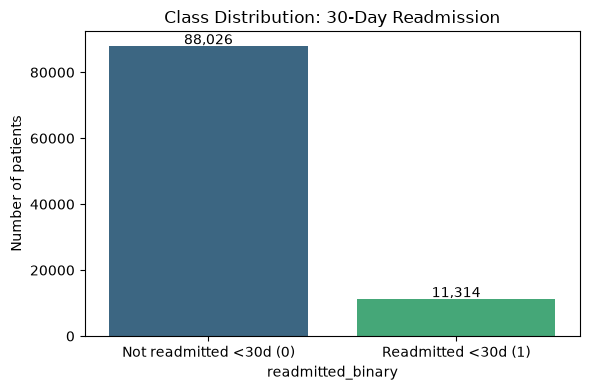


Saved plot: class_distribution.png


In [44]:
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values,
            hue=class_counts.index.astype(str), palette="viridis", legend=False)
plt.xticks([0, 1], ["Not readmitted <30d (0)", "Readmitted <30d (1)"])
plt.ylabel("Number of patients")
plt.title("Class Distribution: 30-Day Readmission")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 500, f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("\nSaved plot: class_distribution.png")

In [46]:
x_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Training set: {x_train.shape[0]:,} samples")
print(f"Test set:     {x_test.shape[0]:,} samples")
print(f"Training set positive rate: {y_train.mean():.4f}")
print(f"Test set positive rate:     {y_test.mean():.4f}")

Training set: 79,472 samples
Test set:     19,868 samples
Training set positive rate: 0.1139
Test set positive rate:     0.1139


In [47]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

In [49]:
models = {
    "baseline (no class weighting)": LogisticRegression(
        penalty="l2", C=1.0, solver="lbfgs",
        max_iter=2000, random_state=RANDOM_STATE
    ),
    "balanced (class_weight='balanced')": LogisticRegression(
        penalty="l2", C=1.0, solver="lbfgs",
        max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced"
    ),
}


fitted_pipelines = {}
results = {}
 
for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf),
    ])
    pipe.fit(x_train, y_train)
    fitted_pipelines[name] = pipe
 
    y_pred = pipe.predict(x_test)
    y_proba = pipe.predict_proba(x_test)[:, 1]
 
    results[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    print(f"\n--- {name} ---")
    print(f"ROC-AUC:   {results[name]['roc_auc']:.4f}")
    print(f"Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall:    {results[name]['recall']:.4f}")
    print(f"F1-score:  {results[name]['f1']:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["Not <30d", "<30d"],
                                 zero_division=0))


--- baseline (no class weighting) ---
ROC-AUC:   0.6707
Accuracy:  0.8859
Precision: 0.4778
Recall:    0.0190
F1-score:  0.0365

Classification report:
              precision    recall  f1-score   support

    Not <30d       0.89      1.00      0.94     17605
        <30d       0.48      0.02      0.04      2263

    accuracy                           0.89     19868
   macro avg       0.68      0.51      0.49     19868
weighted avg       0.84      0.89      0.84     19868


--- balanced (class_weight='balanced') ---
ROC-AUC:   0.6703
Accuracy:  0.6734
Precision: 0.1871
Recall:    0.5581
F1-score:  0.2802

Classification report:
              precision    recall  f1-score   support

    Not <30d       0.92      0.69      0.79     17605
        <30d       0.19      0.56      0.28      2263

    accuracy                           0.67     19868
   macro avg       0.56      0.62      0.53     19868
weighted avg       0.84      0.67      0.73     19868



In [52]:
comparison_df = pd.DataFrame({
    name: {
        "ROC-AUC": r["roc_auc"], "Accuracy": r["accuracy"],
        "Precision": r["precision"], "Recall": r["recall"], "F1": r["f1"],
    } for name, r in results.items()
}).T
print(comparison_df.round(4))
print(
    "\nNote: ROC-AUC is threshold-independent, so it barely changes between "
    "the two models - class_weight mainly shifts WHERE the default 0.5 "
    "threshold falls relative to the predicted probabilities, trading "
    "precision for recall. The balanced model typically achieves much "
    "higher recall (catches more true 30-day readmissions) at the cost of "
    "lower precision (more false alarms)."
)


FINAL_MODEL_NAME = "balanced (class_weight='balanced')"
final_pipeline = fitted_pipelines[FINAL_MODEL_NAME]
final_result = results[FINAL_MODEL_NAME]
y_pred_final = final_result["y_pred"]
y_proba_final = final_result["y_proba"]
 
print(f"\n>>> Final model selected for detailed evaluation: {FINAL_MODEL_NAME} <<<")

                                    ROC-AUC  Accuracy  Precision  Recall  \
baseline (no class weighting)        0.6707    0.8859     0.4778  0.0190   
balanced (class_weight='balanced')   0.6703    0.6734     0.1871  0.5581   

                                        F1  
baseline (no class weighting)       0.0365  
balanced (class_weight='balanced')  0.2802  

Note: ROC-AUC is threshold-independent, so it barely changes between the two models - class_weight mainly shifts WHERE the default 0.5 threshold falls relative to the predicted probabilities, trading precision for recall. The balanced model typically achieves much higher recall (catches more true 30-day readmissions) at the cost of lower precision (more false alarms).

>>> Final model selected for detailed evaluation: balanced (class_weight='balanced') <<<



Confusion matrix (rows = actual, columns = predicted):
[[12116  5489]
 [ 1000  1263]]

True Negatives  (correctly predicted NOT readmitted): 12,116
False Positives (predicted readmitted, actually NOT):  5,489
False Negatives (predicted NOT readmitted, actually WAS): 1,000
True Positives  (correctly predicted readmitted):      1,263


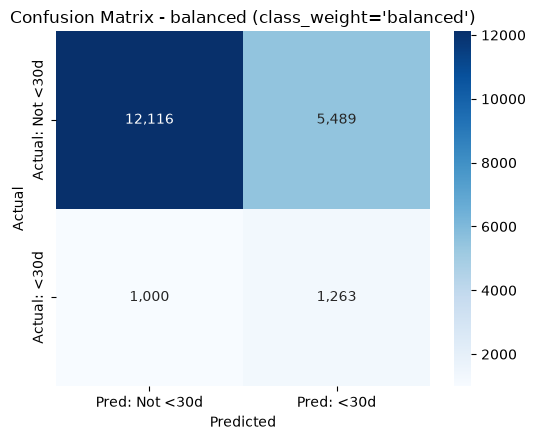


Saved plot: confusion_matrix.png


In [53]:
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion matrix (rows = actual, columns = predicted):")
print(cm)
print(f"\nTrue Negatives  (correctly predicted NOT readmitted): {tn:,}")
print(f"False Positives (predicted readmitted, actually NOT):  {fp:,}")
print(f"False Negatives (predicted NOT readmitted, actually WAS): {fn:,}")
print(f"True Positives  (correctly predicted readmitted):      {tp:,}")


plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Pred: Not <30d", "Pred: <30d"],
            yticklabels=["Actual: Not <30d", "Actual: <30d"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"Confusion Matrix - {FINAL_MODEL_NAME}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("\nSaved plot: confusion_matrix.png")

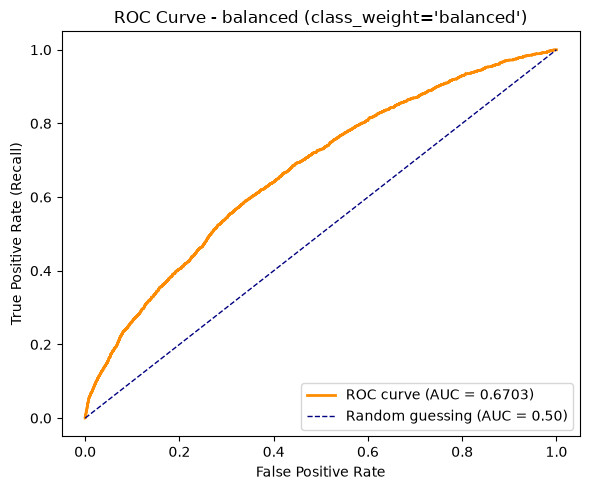

Saved plot: roc_curve.png


In [54]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {final_result['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--",
         label="Random guessing (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title(f"ROC Curve - {FINAL_MODEL_NAME}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print("Saved plot: roc_curve.png")

In [55]:
print(f"""
WHAT ROC-AUC MEANS HERE
------------------------
ROC-AUC ({final_result['roc_auc']:.4f}) is the probability that, if we pick one
randomly chosen readmitted patient and one randomly chosen non-readmitted
patient, the model assigns a higher predicted risk score to the readmitted
patient. A value of 0.5 means the model is no better than random guessing;
1.0 means perfect separation. Unlike accuracy, ROC-AUC does not depend on
choosing a specific probability threshold, which makes it a good summary
metric for an imbalanced classification problem like this one.
 
FALSE NEGATIVES (FN = {fn:,} patients in the test set)
------------------------------------------------------
A false negative is a patient the model predicts will NOT be readmitted
within 30 days, but who actually IS readmitted. This is the most
clinically dangerous type of error: the patient leaves the hospital
without being flagged for extra follow-up (e.g. a post-discharge phone
call, closer medication monitoring, an earlier follow-up appointment),
and may deteriorate at home until an emergency readmission becomes
necessary - worse health outcomes, and often a more expensive and urgent
episode of care than a planned intervention would have been.
 
FALSE POSITIVES (FP = {fp:,} patients in the test set)
------------------------------------------------------
A false positive is a patient predicted to be at high risk of readmission
who, in reality, does fine and is not readmitted. These errors are not
free either: they can trigger unnecessary follow-up calls or visits,
extra diagnostic testing, added workload for already-stretched clinical
staff, and higher healthcare spending on interventions the patient did
not actually need. At scale, too many false positives can also cause
"alert fatigue," where staff start to distrust or ignore the model's
warnings altogether.
 
WHY 0.5 IS NOT NECESSARILY THE RIGHT THRESHOLD
------------------------------------------------
By default, LogisticRegression.predict() classifies a patient as
"high risk" only if its predicted probability exceeds 0.5. But 0.5 is
an arbitrary cutoff with no inherent clinical meaning - it simply treats
false negatives and false positives as equally costly. In this setting
they are not: missing a true readmission (FN) can mean a preventable
health crisis, while a false alarm (FP) mainly costs staff time and
money. In practice, hospitals typically LOWER the threshold below 0.5
(e.g. to 0.2-0.3) so that the model flags more patients as high-risk,
accepting more false positives in exchange for catching more true
positives - the right trade-off point should be chosen using the ROC
curve above together with the real-world costs of each error type, not
by defaulting to 0.5.
""")


WHAT ROC-AUC MEANS HERE
------------------------
ROC-AUC (0.6703) is the probability that, if we pick one
randomly chosen readmitted patient and one randomly chosen non-readmitted
patient, the model assigns a higher predicted risk score to the readmitted
patient. A value of 0.5 means the model is no better than random guessing;
1.0 means perfect separation. Unlike accuracy, ROC-AUC does not depend on
choosing a specific probability threshold, which makes it a good summary
metric for an imbalanced classification problem like this one.

FALSE NEGATIVES (FN = 1,000 patients in the test set)
------------------------------------------------------
A false negative is a patient the model predicts will NOT be readmitted
within 30 days, but who actually IS readmitted. This is the most
clinically dangerous type of error: the patient leaves the hospital
without being flagged for extra follow-up (e.g. a post-discharge phone
call, closer medication monitoring, an earlier follow-up appointment),
an

In [56]:
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = final_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)
 
n_top = 15
print(f"\nTop {n_top} features associated with HIGHER predicted readmission risk "
      "(largest positive coefficients):")
print(coef_df.head(n_top).to_string(index=False))
 
print(f"\nTop {n_top} features associated with LOWER predicted readmission risk "
      "(largest negative coefficients):")
print(coef_df.tail(n_top).sort_values("coefficient").to_string(index=False))
 
print("""
IMPORTANT CAVEAT: ASSOCIATION IS NOT CAUSATION
------------------------------------------------
These coefficients describe statistical ASSOCIATIONS learned from
historical hospital data, not proven causal effects. For example, if
"number_inpatient" (prior inpatient visits) has a strong positive
coefficient, it means patients with more past inpatient stays tend to
have higher predicted readmission risk in this dataset - it does NOT
mean that having more inpatient visits directly CAUSES readmission.
The true underlying cause is more likely an unmeasured factor such as
disease severity or chronic illness burden, which independently drives
both past hospitalizations and future readmission risk (i.e.
confounding). These coefficients should guide further clinical
investigation and hypothesis generation, not be treated as proven
causal mechanisms or used in isolation for high-stakes clinical
decisions.
""")


Top 15 features associated with HIGHER predicted readmission risk (largest positive coefficients):
                                           feature  coefficient
                  cat__discharge_disposition_id_15     1.352435
                  cat__discharge_disposition_id_28     1.217246
                   cat__discharge_disposition_id_9     1.048748
       cat__medical_specialty_AllergyandImmunology     1.024585
            cat__medical_specialty_Surgery-Plastic     0.943006
        cat__medical_specialty_Hematology/Oncology     0.911623
                 cat__medical_specialty_Hematology     0.886600
                  cat__discharge_disposition_id_22     0.882849
               cat__medical_specialty_Rheumatology     0.675385
                      cat__diag_1_category_Missing     0.674129
cat__medical_specialty_Psychiatry-Child/Adolescent     0.659391
       cat__medical_specialty_Cardiology-Pediatric     0.586427
                        cat__admission_source_id_8     0.547163
    

In [57]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)
 
n_top = 15
print(f"\nTop {n_top} features associated with HIGHER predicted readmission risk "
      "(largest positive coefficients):")
print(coef_df.head(n_top).to_string(index=False))
 
print(f"\nTop {n_top} features associated with LOWER predicted readmission risk "
      "(largest negative coefficients):")
print(coef_df.tail(n_top).sort_values("coefficient").to_string(index=False))
 
print("""
IMPORTANT CAVEAT: ASSOCIATION IS NOT CAUSATION
------------------------------------------------
These coefficients describe statistical ASSOCIATIONS learned from
historical hospital data, not proven causal effects. For example, if
"number_inpatient" (prior inpatient visits) has a strong positive
coefficient, it means patients with more past inpatient stays tend to
have higher predicted readmission risk in this dataset - it does NOT
mean that having more inpatient visits directly CAUSES readmission.
The true underlying cause is more likely an unmeasured factor such as
disease severity or chronic illness burden, which independently drives
both past hospitalizations and future readmission risk (i.e.
confounding). These coefficients should guide further clinical
investigation and hypothesis generation, not be treated as proven
causal mechanisms or used in isolation for high-stakes clinical
decisions.
""")


Top 15 features associated with HIGHER predicted readmission risk (largest positive coefficients):
                                           feature  coefficient
                  cat__discharge_disposition_id_15     1.352435
                  cat__discharge_disposition_id_28     1.217246
                   cat__discharge_disposition_id_9     1.048748
       cat__medical_specialty_AllergyandImmunology     1.024585
            cat__medical_specialty_Surgery-Plastic     0.943006
        cat__medical_specialty_Hematology/Oncology     0.911623
                 cat__medical_specialty_Hematology     0.886600
                  cat__discharge_disposition_id_22     0.882849
               cat__medical_specialty_Rheumatology     0.675385
                      cat__diag_1_category_Missing     0.674129
cat__medical_specialty_Psychiatry-Child/Adolescent     0.659391
       cat__medical_specialty_Cardiology-Pediatric     0.586427
                        cat__admission_source_id_8     0.547163
    

In [59]:
n_features_after_preprocessing = final_pipeline.named_steps["preprocessor"].transform(
    x_train.iloc[:1]
).shape[1]
 
print("\n" + "=" * 78)
print("FINAL SUMMARY")
print("=" * 78)
print(f"Model used for summary:        {FINAL_MODEL_NAME}")
print(f"Total samples (after cleaning): {len(df):,}")
print(f"  Training samples:             {x_train.shape[0]:,}")
print(f"  Test samples:                 {x_test.shape[0]:,}")
print(f"Number of raw input features:   {len(numeric_features) + len(categorical_features)} "
      f"({len(numeric_features)} numeric + {len(categorical_features)} categorical)")
print(f"Number of features after preprocessing (one-hot expanded): "
      f"{n_features_after_preprocessing}")
print(f"ROC-AUC:                        {final_result['roc_auc']:.4f}")
print(f"Accuracy:                       {final_result['accuracy']:.4f}")
print(f"Precision:                      {final_result['precision']:.4f}")
print(f"Recall:                         {final_result['recall']:.4f}")
print(f"F1-score:                       {final_result['f1']:.4f}")
print("=" * 78)
print("Plots saved to: class_distribution.png, confusion_matrix.png, roc_curve.png")
print("=" * 78)


FINAL SUMMARY
Model used for summary:        balanced (class_weight='balanced')
Total samples (after cleaning): 99,340
  Training samples:             79,472
  Test samples:                 19,868
Number of raw input features:   43 (8 numeric + 35 categorical)
Number of features after preprocessing (one-hot expanded): 253
ROC-AUC:                        0.6703
Accuracy:                       0.6734
Precision:                      0.1871
Recall:                         0.5581
F1-score:                       0.2802
Plots saved to: class_distribution.png, confusion_matrix.png, roc_curve.png
